In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/shahedurrahmanrafin/capstone-csv-file/DiaBD_A Diabetes Dataset for Enhanced Risk Analysis and Research in Bangladesh.csv


Dataset Loaded Successfully
Dataset Shape: (5288, 15)
After Column Drop: (5288, 11)


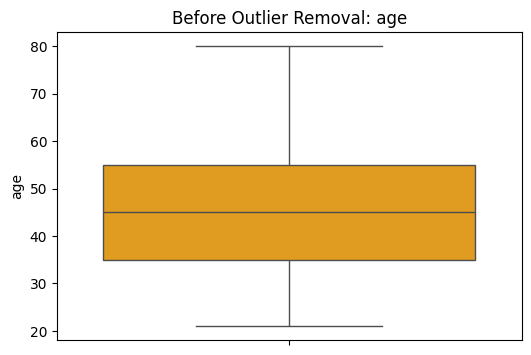

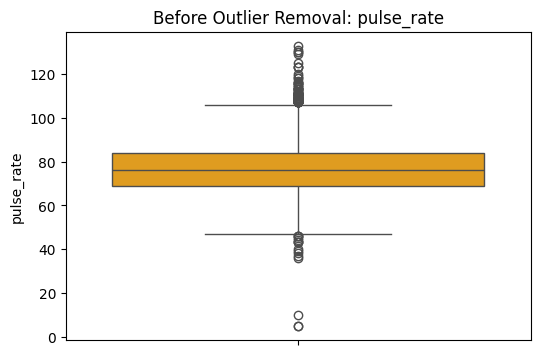

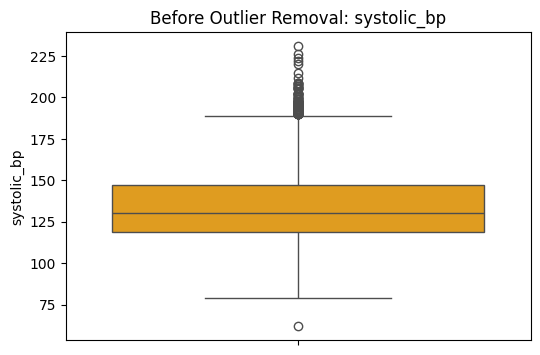

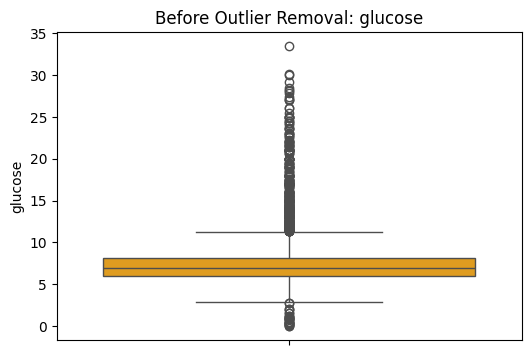

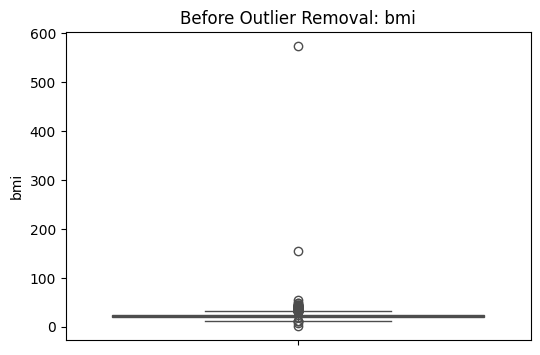

Shape After Outlier Removal: (4586, 11)


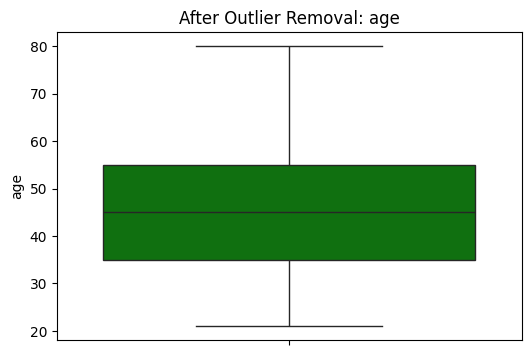

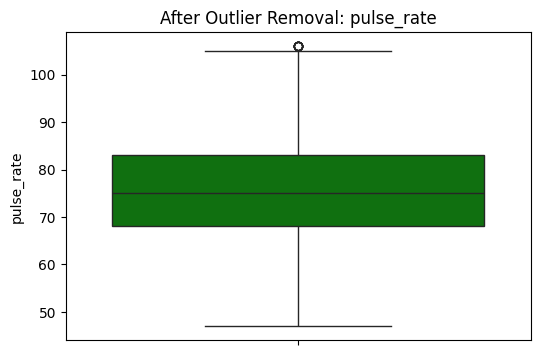

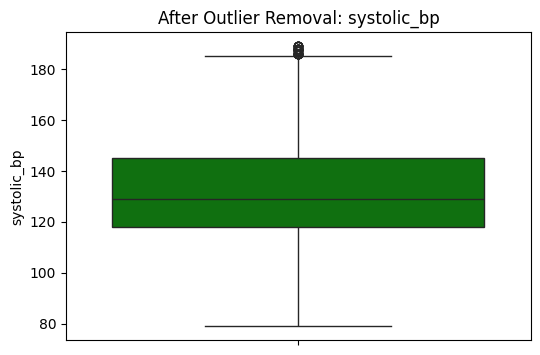

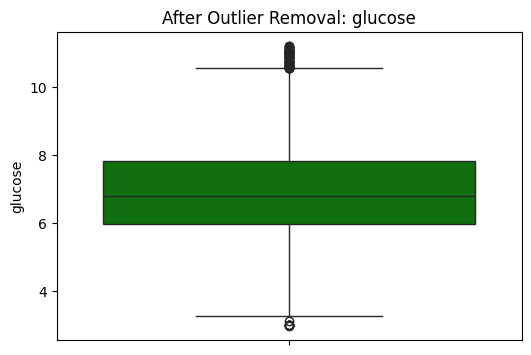

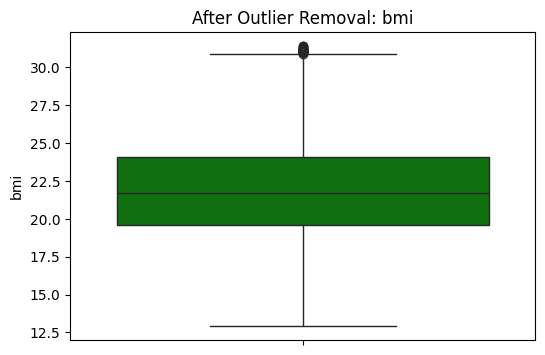

Clean dataset saved at: /kaggle/working/clean_diabetes_no_outliers.csv


In [2]:
# =========================================
# Import Libraries
# =========================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# =========================================
# Dataset Path
# =========================================

file_path = "/kaggle/input/datasets/shahedurrahmanrafin/capstone-csv-file/DiaBD_A Diabetes Dataset for Enhanced Risk Analysis and Research in Bangladesh.csv"

df = pd.read_csv(file_path)

print("Dataset Loaded Successfully")
print("Dataset Shape:", df.shape)

# =========================================
# Drop Unnecessary Columns (Based on Analysis Table)
# =========================================

columns_to_drop = [
    "diastolic_bp",
    "height",
    "weight",
    "family_hypertension"
]

df_clean = df.drop(columns=columns_to_drop)

print("After Column Drop:", df_clean.shape)

# =========================================
# Numerical Features for Outlier Detection
# =========================================

numerical_features = [
    "age",
    "pulse_rate",
    "systolic_bp",
    "glucose",
    "bmi"
]

# =========================================
# BEFORE CLEANING VISUALIZATION
# =========================================

for feature in numerical_features:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        y=df_clean[feature],
        color="orange"
    )

    plt.title(f"Before Outlier Removal: {feature}")

    plt.show()

# =========================================
# OUTLIER REMOVAL USING IQR METHOD
# =========================================

df_outlier_clean = df_clean.copy()

for feature in numerical_features:

    Q1 = df_outlier_clean[feature].quantile(0.25)
    Q3 = df_outlier_clean[feature].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_outlier_clean = df_outlier_clean[
        (df_outlier_clean[feature] >= lower_bound) &
        (df_outlier_clean[feature] <= upper_bound)
    ]

print("Shape After Outlier Removal:", df_outlier_clean.shape)

# =========================================
# AFTER CLEANING VISUALIZATION
# =========================================

for feature in numerical_features:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        y=df_outlier_clean[feature],
        color="green"
    )

    plt.title(f"After Outlier Removal: {feature}")

    plt.show()

# =========================================
# Save Clean Dataset
# =========================================

output_path = "/kaggle/working/clean_diabetes_no_outliers.csv"

df_outlier_clean.to_csv(output_path, index=False)

print("Clean dataset saved at:", output_path)